# Интернет-магазин. Анализ результатов A/B-тестирования

**Контекст**: представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

**Содержание:**
- Цели и исходные данные;
- Загрузка данных и знакомство с ними;
- Проверка корректности теста;
- Оценка результатов АВ-теста
- Выводы

## Цели исследования



**Цель:** оценить эффективность изменения интерфейса сайта интернет-магазина по результатам A/B-теста.

**Проверяемая гипотеза:** упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта.

**Описание данных:**

Таблица **participants** с участниками теста:
 - `user_id` - идентификатор пользователя;
 - `group` - группа пользователя;
 - `ab_test` - название теста;
 - `device` - устройство, с которого происходила регистрация.

Таблица **events** - события за 2020 год:
 - `user_id` - идентификатор пользователя;
 - `event_dt` - дата и время события;
 - `event_name` - тип события;
 - `details` - дополнительные данные о событии

**Дополнительные сведения по А/В-тесту:** 

Параметры теста:

- название теста: interface_eu_test;
- группы: А (контрольная), B (новый интерфейс).

## Загрузка данных, оценка их целостности


In [1]:
# Импортируем библиотеки
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats as st

from scipy.stats import ttest_ind

In [2]:
participants = pd.read_csv(r'..\..\Data (csv)\Файлы. Интернет-магазин\ab_test_participants.csv')
events = pd.read_csv(r'..\..\Data (csv)\Файлы. Интернет-магазин\ab_test_events.csv',
                     parse_dates=['event_dt'], low_memory=False)

In [3]:
# Посмотрим на данные
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [4]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


Выведем общую информацию по каждому датасету

In [5]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [6]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


Итак, мы видим что в обоих датасетах в ключевых столбцах отсутствуют пропуски, а содержимое и типы данных соответствуют описанию.

Поскольку ключевая метрика теста - это конверсия зарегистрированных пользователей в покупателей, для дальнейшего анализа нужно определить как в таблице `events` отмечаются покупки пользователей (регистрация - это registration). Для этого выведем список уникальных значений столбца `event_name`

In [7]:
events_list = events['event_name'].unique()

events_list

array(['End of Black Friday Ads Campaign', 'registration', 'product_page',
       'login', 'product_cart', 'purchase',
       'Start of Christmas&New Year Promo',
       'Start of CIS New Year Gift Lottery'], dtype=object)

Итак, регистрация пользователей записывается как registration, а покупка - purchase

Для дальнейшей работы объединим датасеты в один

In [8]:
df = participants.merge(events, on = 'user_id', how = 'inner')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104558 entries, 0 to 104557
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     104558 non-null  object        
 1   group       104558 non-null  object        
 2   ab_test     104558 non-null  object        
 3   device      104558 non-null  object        
 4   event_dt    104558 non-null  datetime64[ns]
 5   event_name  104558 non-null  object        
 6   details     27878 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 5.6+ MB


Таким образом, рабочий датафрейм содержит 104558 строк и 7 столбцов

## По таблице `participants` оценим корректность проведения теста:

### Проверка соответствия требованиям технического задания

In [9]:
# Отфильтруем данные по названию теста
ab_test_participants = df[df['ab_test']=='interface_eu_test']

ab_test_participants.head()

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN


In [10]:
ab_test_participants.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79715 entries, 0 to 104557
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     79715 non-null  object        
 1   group       79715 non-null  object        
 2   ab_test     79715 non-null  object        
 3   device      79715 non-null  object        
 4   event_dt    79715 non-null  datetime64[ns]
 5   event_name  79715 non-null  object        
 6   details     21075 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 4.9+ MB


Итак, пропусков нет, а датафрейм уменьшился в объеме.

### Оценим равномерность распределения выборок

In [11]:
# Посчитаем количество пользователей по группам
group_a = ab_test_participants.loc[ab_test_participants['group']== 'A']
group_b = ab_test_participants.loc[ab_test_participants['group']== 'B']

count_a = group_a.groupby('group')['user_id'].nunique().reset_index()
count_b = group_b.groupby('group')['user_id'].nunique().reset_index()

print(f'В группе А число пользователей: {count_a.iloc[0,1]}, в группе В: {count_b.iloc[0,1]}, относительная разница: {1 - count_a.iloc[0,1] / count_b.iloc[0,1]:.2%}')

В группе А число пользователей: 5383, в группе В: 5467, относительная разница: 1.54%


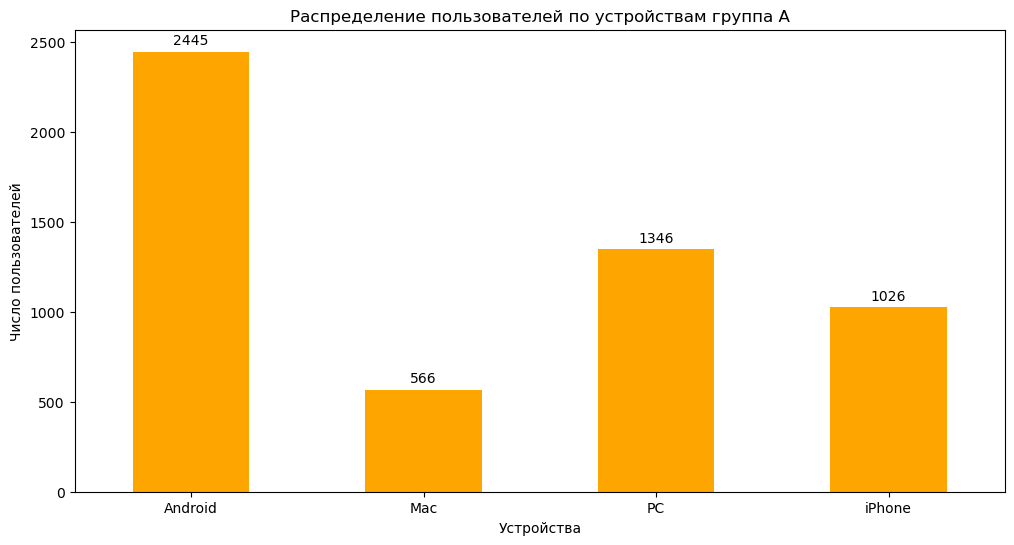

In [12]:
# Оценим распределение выборок по устройствам
# Группа А
group_a_devices = group_a.groupby('device')['user_id'].nunique()

plt.figure(figsize = (12,6))

ax = group_a_devices.plot(kind='bar',
                    color = 'orange',
                    title = 'Распределение пользователей по устройствам группа А',
                    xlabel = 'Устройства',
                    ylabel= 'Число пользователей',
                    rot = 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=10,
                xytext=(0, 3), textcoords='offset points')

plt.show()

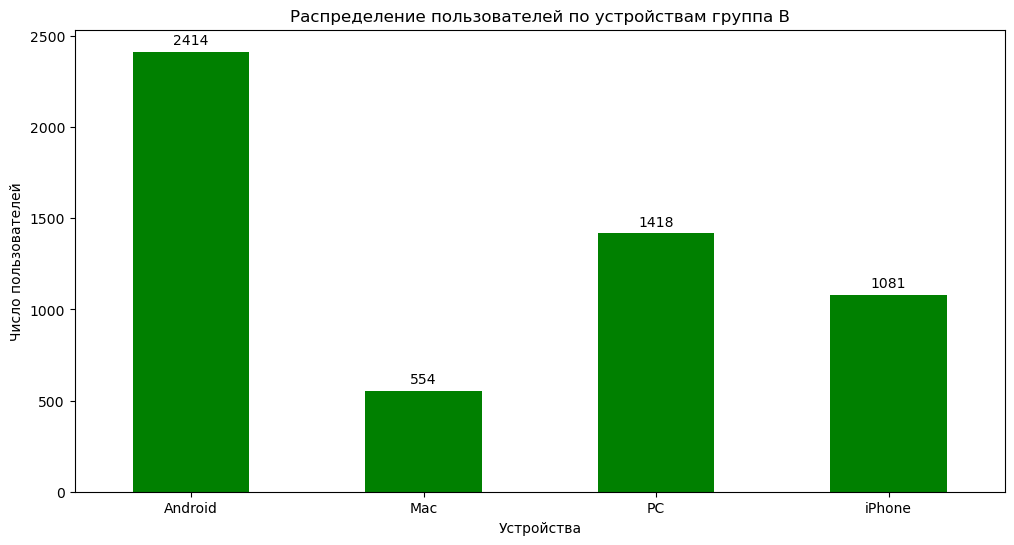

In [13]:
# Оценим распределение выборок по устройствам
# Группа B
group_b_devices = group_b.groupby('device')['user_id'].nunique()

plt.figure(figsize = (12,6))

ax = group_b_devices.plot(kind='bar',
                    color = 'green',
                    title = 'Распределение пользователей по устройствам группа B',
                    xlabel = 'Устройства',
                    ylabel= 'Число пользователей',
                    rot = 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=10,
                xytext=(0, 3), textcoords='offset points')

plt.show()

Сравнение графиков для каждой группы показывает, что распределение пользователей по устройствам примерно равное, следовательно, искажений в тесте по этому критерию быть не должно

### Найдем пересечение двух выборок

In [14]:
find_intersection = ab_test_participants.groupby('user_id',as_index = False)['group'].nunique()

ab_users = find_intersection[find_intersection['group']>1]

ab_users

,user_id,group


Таким образом, пользователей, которые присутствуют в обеих группах, нет.

## Проанализируем данные о пользовательской активности по таблице `events`:

### Отфильтруем датасет по целевым действиям (регистрация и покупка)

In [15]:
ab_test_participants = ab_test_participants[(ab_test_participants['event_name']== 'registration'
                                            )|(
                                            ab_test_participants['event_name']== 'purchase')]
ab_test_participants.head()

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
17,001064FEAAB631A1,A,interface_eu_test,Android,2020-12-20 14:12:45,registration,-2.14
35,001E72F50D1C48FA,A,interface_eu_test,Mac,2020-12-17 15:44:05,registration,-3.61
42,002412F1EB3F6E38,B,interface_eu_test,Mac,2020-12-09 09:36:50,registration,-0.48
50,002540BE89C930FB,B,interface_eu_test,Android,2020-12-08 18:06:07,registration,-2.38


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

### Отфильтруем датасет по действиям пользователей, совершенным до верхней даты исследования (крайняя дата регистрации + 7 дней)

In [16]:
# Создадим столбец с датой: дата регистрации + 7 дней для каждой строки
registration_df = ab_test_participants.loc[ab_test_participants['event_name'] == 'registration'].copy()

registration_df['upper_date_limit'] = registration_df['event_dt'] + pd.Timedelta(days=7)

test_df = ab_test_participants.merge(registration_df[['user_id','upper_date_limit']],on='user_id',how = 'inner')

test_df

,user_id,group,ab_test,device,event_dt,event_name,details,upper_date_limit
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38,2020-12-14 04:37:31
1,001064FEAAB631A1,A,interface_eu_test,Android,2020-12-20 14:12:45,registration,-2.14,2020-12-27 14:12:45
2,001E72F50D1C48FA,A,interface_eu_test,Mac,2020-12-17 15:44:05,registration,-3.61,2020-12-24 15:44:05
3,002412F1EB3F6E38,B,interface_eu_test,Mac,2020-12-09 09:36:50,registration,-0.48,2020-12-16 09:36:50
4,002540BE89C930FB,B,interface_eu_test,Android,2020-12-08 18:06:07,registration,-2.38,2020-12-15 18:06:07
...,...,...,...,...,...,...,...,...
21070,FFE7FC140521F5F6,A,interface_eu_test,PC,2020-12-26 14:37:21,purchase,4.49,2020-12-30 09:10:16
21071,FFE7FC140521F5F6,A,interface_eu_test,PC,2020-12-26 14:37:51,purchase,4.49,2020-12-30 09:10:16
21072,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,2020-12-13 23:52:15,registration,0.0,2020-12-20 23:52:15
21073,FFF28D02B1EACBE1,B,interface_eu_test,PC,2020-12-16 08:23:56,registration,-0.45,2020-12-23 08:23:56


In [17]:
# Отфильтруем покупки пользователей по верхней дате исследования
purchase_df = test_df[test_df['event_name']=='purchase']

purchase_df = purchase_df[purchase_df['event_dt']<=purchase_df['upper_date_limit']]

# Отдельно сохраним датафрейм только с регистрациями
registration_df = test_df[test_df['event_name']=='registration']

# Объединим строки с регистрациями и покупками
filt_df = pd.concat([registration_df,purchase_df],ignore_index=True)

filt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17473 entries, 0 to 17472
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           17473 non-null  object        
 1   group             17473 non-null  object        
 2   ab_test           17473 non-null  object        
 3   device            17473 non-null  object        
 4   event_dt          17473 non-null  datetime64[ns]
 5   event_name        17473 non-null  object        
 6   details           17473 non-null  object        
 7   upper_date_limit  17473 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(6)
memory usage: 1.1+ MB


Таким образом, после всех фильтраций, датасет для дальнейшего анализа содержит 17473 строки.

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

## Рассчитаем необходимый размер выборки

In [18]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1-beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


Таким образом, необходимый размер каждой выборки меньше, чем фактические размеры групп А и В (примерно по 5,5 тыс.)

## Оценим изменение ключевой метрики

In [19]:
# Общее количество пользователей
group_a = filt_df.loc[filt_df['group']== 'A'].copy()
group_b = filt_df.loc[filt_df['group']== 'B'].copy()

count_a = group_a['user_id'].nunique()
count_b = group_b['user_id'].nunique()

# Количество покупателей
num_customers_a = group_a[group_a['event_name']=='purchase']['user_id'].nunique()
num_customers_b = group_b[group_b['event_name']=='purchase']['user_id'].nunique()

In [20]:
# Посчитаем целевую метрику для каждой группы
conversion_a = round(num_customers_a/count_a,4)
conversion_b = round(num_customers_b/count_b,4)

# Посчитаем разницу между метриками
diff = round(conversion_a - conversion_b,4)

display(f'Группа А: всего пользователей:{count_a}, из них покупателей {num_customers_a}. Группа В всего пользователей:{count_b}, из них покупателей {num_customers_b}. Разница в значении: {diff}')

'Группа А: всего пользователей:5383, из них покупателей 1480. Группа В всего пользователей:5467, из них покупателей 1600. Разница в значении: -0.0178'

По предварительной оценке разница в целевой метрике составляет 1,78% в пользу тестовой группы.

## Оценка результатов A/B-тестирования

### Проверим результат на значимость

*Обозначим гипотезы еще раз:*

**Ключевая метрика:** конверсия зарегистрированных пользователей в покупателей течение 7 дней после регистрации 

**Нулевая гипотеза:** конверсия не изменится, т.е. метрики в контрольной и тестовой группах будут равны

**Альтернативная гипотеза:** ключевая метрика в тестовой группе будет больше, чем в контрольной, минимум на 3 процентных пункта.

In [21]:
# Создадим для каждой группы столбец с бинарным значением: 1 - сделал покупку; 0 - не сделал покупку

# Группа А
group_a['made_purchase'] = 0

list_customers_a = list(group_a[group_a['event_name'] == 'purchase']['user_id'].unique())

group_a.loc[group_a['user_id'].isin(list_customers_a),'made_purchase']=1

test_group_a=group_a.drop_duplicates(subset = 'user_id')['made_purchase']

test_group_a = test_group_a.reset_index(drop=True)

test_group_a

0       0
1       0
2       1
3       0
4       0
       ..
5378    1
5379    0
5380    1
5381    0
5382    0
Name: made_purchase, Length: 5383, dtype: int64

In [22]:
# Группа В
group_b['made_purchase'] = 0

list_customers_b = list(group_b[group_b['event_name'] == 'purchase']['user_id'].unique())

group_b.loc[group_b['user_id'].isin(list_customers_b),'made_purchase']=1

test_group_b=group_b.drop_duplicates(subset = 'user_id')['made_purchase']

test_group_b = test_group_b.reset_index(drop=True)

test_group_b

0       0
1       0
2       0
3       0
4       0
       ..
5462    0
5463    0
5464    0
5465    0
5466    0
Name: made_purchase, Length: 5467, dtype: int64

In [23]:
# Проверим результат теста на значимость

# Получим p-value
result = st.ttest_ind(
    test_group_a,
    test_group_b,
    alternative = 'less'
    )
print(f'р-значение: {result.pvalue}')

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нулевую гипотезу отвергнуть нельзя')

р-значение: 0.0203088631878687
Отвергаем нулевую гипотезу


## Выводы

**Выводы:** в работе проверялась гипотеза: упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта.

Собранные для А/B-теста данные показали, что выборки (А и В) имеют схожее распределение, аномалий в данных нет, пересечений тоже.

Расчет размера выборки показал, что минимальный объем должен быть не менее 3761 ед. на одну группу; в исходных данных выборки содержали информацию об около 5,5 тыс. пользователей каждая.

Предварительный анализ результатов теста показал, что в тестовой группе B конверсия пользователя в покупателя выросла на 1.78% по сравнению с контрольной группой. Дальнейший стат. тест определил результат как значимый.

Таким образом, положительный эффект от упрощения интерфейса действительно определен, однако он оказался не таким большим, как предполагалось в гипотезе - увеличение на 1.78% вместо 3%.